<a href="https://colab.research.google.com/github/geowakup/Purrfect-Match/blob/master/T2620_Assignment_Part_III_Group_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is the template for the students to start working on the Assignment Part II

Import the libraries

In [69]:
import pandas as pd
from pandas import read_csv
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

Load the dataset

In [70]:
import pandas as pd
from pandas import read_csv
df = read_csv("/content/telemetry_churn.csv")
df.head()

,Customer_ID,Tenure_Months,Monthly_Charges,Total_Charges,Contract_Type,Tech_Support_Calls,Churn
0,CUST-100000,51,105.90,4967.53,One year,2,No
1,CUST-100001,14,114.50,1617.26,Month-to-month,0,No
2,CUST-100002,71,56.08,4071.94,Month-to-month,0,No
3,CUST-100003,60,45.62,2551.14,Month-to-month,1,No
4,CUST-100004,20,83.69,1633.42,Month-to-month,3,Yes


What is the dimension of this dataset?

In [71]:
import pandas as pd
from pandas import read_csv
df = read_csv("/content/telemetry_churn.csv")
print(df.shape)

(1000, 7)


In [72]:
df.describe()

,Tenure_Months,Monthly_Charges,Total_Charges,Tech_Support_Calls
count,1000.000000,1000.000000,980.000000,1000.000000
mean,35.238000,69.234440,2365.870735,1.457000
std,21.184809,29.981947,1884.049730,1.158228
min,0.000000,18.500000,1.270000,0.000000
25%,17.000000,42.212500,868.347500,1.000000
50%,35.000000,70.400000,1816.925000,1.000000
75%,54.000000,95.340000,3590.572500,2.000000
max,72.000000,119.940000,8406.440000,6.000000


How many types of fault?

In [73]:
import pandas as pd
from pandas import read_csv
df = read_csv("/content/telemetry_churn.csv")
target_col = [col for col in df.columns if 'churn' in col.lower() or 'class' in col.lower() or df[col].dtype == 'object'][-1]
y = df[target_col]
print(y.value_counts())

Churn
No     800
Yes    200
Name: count, dtype: int64


Check for NaN

In [74]:
df.isna().sum()

,0
Customer_ID,0
Tenure_Months,0
Monthly_Charges,0
Total_Charges,20
Contract_Type,0
Tech_Support_Calls,0
Churn,0


Check for NaN. Note that `fault_columns` are our targets (y) and the rest are features (X).

In [75]:
import pandas as pd
from pandas import read_csv
df = read_csv("/content/telemetry_churn.csv")
target_col = [col for col in df.columns if 'churn' in col.lower() or 'class' in col.lower() or df[col].dtype == 'object'][-1]
X = df.drop(columns=[target_col]).select_dtypes(include=['number'])
y = df[target_col]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 4)
y shape: (1000,)


**Dimensionality Reduction**  
Reduce the dimensionality to only 5 features using PCA

In [76]:
import pandas as pd
from pandas import read_csv
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

df = read_csv("/content/telemetry_churn.csv")
target_col = [col for col in df.columns if 'churn' in col.lower() or 'class' in col.lower() or df[col].dtype == 'object'][-1]
X = df.drop(columns=[target_col]).select_dtypes(include=['number'])

# Impute missing values (e.g. in Total_Charges) before scaling
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
print("Scaled features shape:", X_scaled.shape)

Scaled features shape: (1000, 4)


Which features are the most important?

In [77]:
from sklearn.decomposition import PCA
import numpy as np

# The dataset has 4 numeric features, so we can use up to 4 components for PCA
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)
print("PCA shape:", X_pca.shape)

loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(4)], index=X.columns)
weighted_importances = np.abs(loadings) * pca.explained_variance_ratio_
overall_importance = weighted_importances.sum(axis=1).sort_values(ascending=False)
print("Top overall important features:")
print(overall_importance)

PCA shape: (1000, 4)
Top overall important features:
Tenure_Months         0.486986
Monthly_Charges       0.482895
Total_Charges         0.358498
Tech_Support_Calls    0.349607
dtype: float64


From here, we notice that '`Y_Maximum`' is the most important feature, followed by '`Sum_of_Luminosity`'.

Get the index of the maximum value in each column (principal component)

In [78]:
import numpy as np
for i, pc in enumerate(loadings.columns):
    max_idx = np.abs(loadings[pc]).idxmax()
    print(f"{pc} most important feature: {max_idx}")

PC1 most important feature: Total_Charges
PC2 most important feature: Monthly_Charges
PC3 most important feature: Tech_Support_Calls
PC4 most important feature: Total_Charges


**k-Means Clustering**

In [79]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
kmeans.fit(X_pca)
clusters = kmeans.labels_

What is the Silhouette Coefficient?

In [80]:
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(X_pca, clusters)
print(f"Silhouette Coefficient: {sil_score:.4f}")

Silhouette Coefficient: 0.3135


Before and after clustering

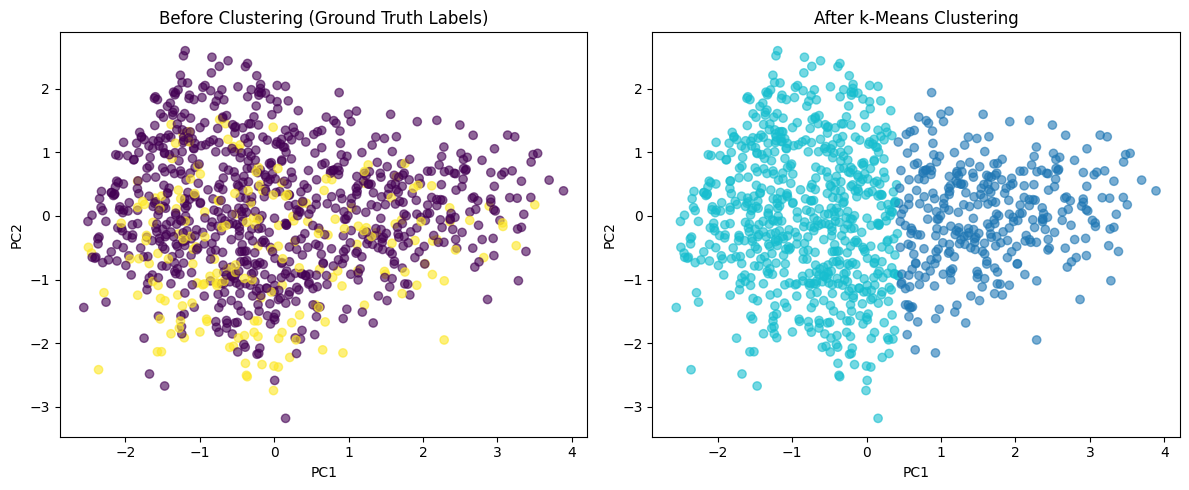

In [81]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
y_labels = y.astype('category').cat.codes

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_labels, cmap='viridis', alpha=0.6)
plt.title('Before Clustering (Ground Truth Labels)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', alpha=0.6)
plt.title('After k-Means Clustering')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.tight_layout()
plt.show()